# Value at Risk and Conditional Value at Risk

**Value at Risk (VaR)** answers: *what is the worst loss we expect over a given horizon, with a given confidence?* At 95 % confidence, VaR is the 5th percentile of the empirical return distribution — 95 % of returns are above it, 5 % below.

**Conditional Value at Risk (CVaR)**, also called Expected Shortfall, is the *mean* of the returns at or below the VaR threshold. CVaR is a coherent risk measure (it satisfies subadditivity); VaR is not. CVaR is also sometimes called the *tail mean* or the *worst-case expected loss*.

This notebook walks through:

1. Loading data and basic EDA on the return distribution.
2. Visualising the tails that VaR and CVaR target.
3. Computing both measures with `get_var` / `get_cvar`.
4. Comparing risk across asset classes.
5. The effect of changing the confidence level.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from portfolio.data import DataIngestion
from portfolio.models.risk import get_cvar, get_var

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ingestion = DataIngestion()
all_prices = ingestion.get_all_prices()
all_returns = DataIngestion.compute_returns(all_prices)

[                       0%                       ]

[*                      2%                       ]  2 of 122 completed

[*                      2%                       ]  3 of 122 completed

[*                      3%                       ]  4 of 122 completed

[***                    6%                       ]  7 of 122 completed

...

[**********************97%********************** ]  118 of 122 completed

[**********************98%********************** ]  119 of 122 completed

[**********************98%********************** ]  120 of 122 completed

[**********************99%***********************]  121 of 122 completed

[*********************100%***********************]  122 of 122 completed

## 2. EDA — descriptive statistics of returns

VaR and CVaR are functions of the empirical return distribution, so the first thing to inspect is its shape. The two diagnostics that matter most are **skewness** (asymmetry) and **kurtosis** (tail heaviness). A normal distribution has skew 0 and excess kurtosis 0; financial returns typically have negative skew and positive excess kurtosis.

In [2]:
flat = all_returns.stack().to_numpy()
flat = flat[np.isfinite(flat)]

summary = pd.Series({
    "observations": len(flat),
    "mean": flat.mean(),
    "std": flat.std(ddof=1),
    "min": flat.min(),
    "5th percentile": np.percentile(flat, 5),
    "median": np.median(flat),
    "95th percentile": np.percentile(flat, 95),
    "max": flat.max(),
    "skewness": stats.skew(flat),
    "excess kurtosis": stats.kurtosis(flat),
})
summary

observations       1952.000000
mean                  0.003285
std                   0.071748
min                  -0.667442
5th percentile       -0.094936
median                0.000000
95th percentile       0.117354
max                   0.818921
skewness              1.222522
excess kurtosis      17.752591
dtype: float64

### Visualising the distribution

Plotting the histogram alongside a fitted normal distribution shows the fat tails — there are far more extreme returns than Gaussian theory predicts. This is precisely why historical VaR (non-parametric) is preferred over parametric VaR for tail estimation.

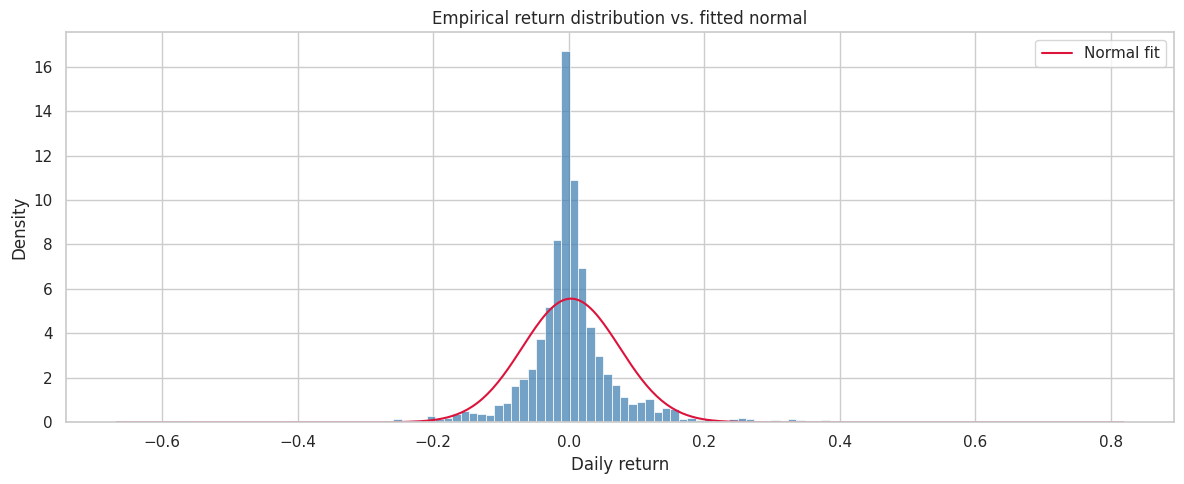

In [3]:
fig, ax = plt.subplots()
sns.histplot(flat, bins=120, stat="density", color="steelblue", ax=ax)
x = np.linspace(flat.min(), flat.max(), 400)
ax.plot(x, stats.norm.pdf(x, flat.mean(), flat.std()),
        color="crimson", linewidth=1.5, label="Normal fit")
ax.set_xlabel("Daily return")
ax.set_ylabel("Density")
ax.set_title("Empirical return distribution vs. fitted normal")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Computing VaR and CVaR

`get_var(prices, confidence)` returns the historical VaR; `get_cvar(prices, confidence)` returns the historical CVaR. The default confidence is 95 % (`config.confidence_level_95`).

In [4]:
var_95 = get_var(all_prices, confidence=0.95)
cvar_95 = get_cvar(all_prices, confidence=0.95)

print(f"VaR  (95%): {var_95:.6f}")
print(f"CVaR (95%): {cvar_95:.6f}")

VaR  (95%): -0.094936
CVaR (95%): -0.153594


### Visualising VaR / CVaR on the return distribution

The dashed lines mark VaR and CVaR. CVaR sits to the left of VaR by construction — it is the *mean* of the tail that begins at VaR.

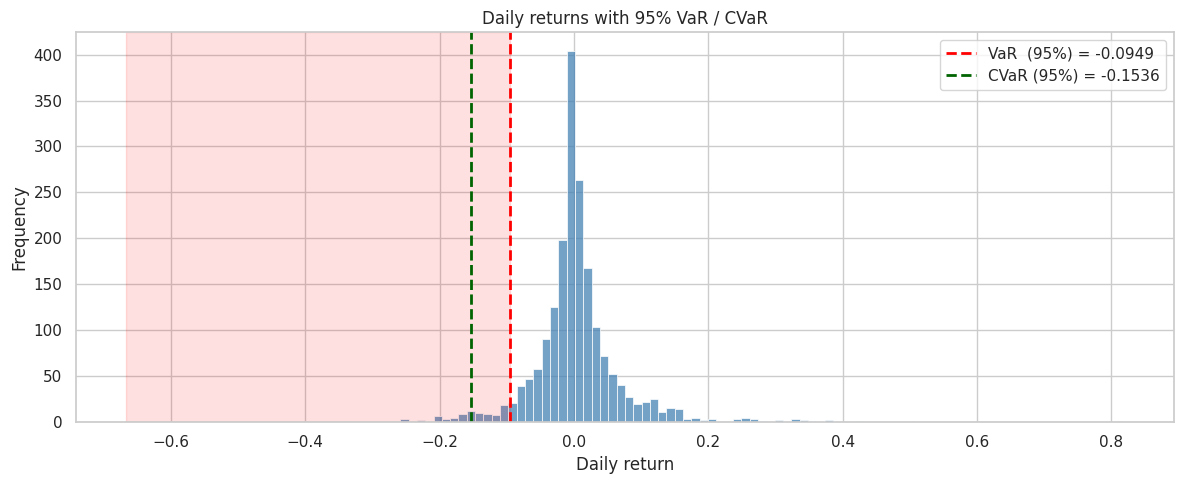

In [5]:
fig, ax = plt.subplots()
sns.histplot(flat, bins=120, color="steelblue", ax=ax)
ax.axvline(var_95, color="red", linestyle="--", linewidth=2,
           label=f"VaR  (95%) = {var_95:.4f}")
ax.axvline(cvar_95, color="darkgreen", linestyle="--", linewidth=2,
           label=f"CVaR (95%) = {cvar_95:.4f}")
ax.axvspan(flat.min(), var_95, alpha=0.12, color="red")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
ax.set_title("Daily returns with 95% VaR / CVaR")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Comparing asset classes

Computing the same measures on subsets of the universe makes the relative riskiness of each asset class concrete. Crypto's tail is dramatically wider than bonds — exactly what VaR/CVaR are designed to make legible.

In [6]:
asset_classes = {
    "stocks": ingestion.get_stock_prices(),
    "etfs":   ingestion.get_etf_prices(),
    "bonds":  ingestion.get_bond_prices(),
    "crypto": ingestion.get_crypto_prices(),
}

rows = []
for name, prices in asset_classes.items():
    rows.append({
        "asset_class": name,
        "VaR_95": get_var(prices, 0.95),
        "CVaR_95": get_cvar(prices, 0.95),
        "VaR_99": get_var(prices, 0.99),
        "CVaR_99": get_cvar(prices, 0.99),
    })
comparison = pd.DataFrame(rows).set_index("asset_class")
comparison

[                       0%                       ]

[**                     4%                       ]  2 of 54 completed

[***                    6%                       ]  3 of 54 completed

[***                    7%                       ]  4 of 54 completed

[****                   9%                       ]  5 of 54 completed

...

[**********************88%*****************      ]  23 of 26 completed

[**********************92%*******************    ]  24 of 26 completed

[**********************96%*********************  ]  25 of 26 completed

[*********************100%***********************]  26 of 26 completed

,VaR_95,CVaR_95,VaR_99,CVaR_99
asset_class,,,,
stocks,-0.056897,-0.088390,-0.100663,-0.141874
etfs,-0.146625,-0.194975,-0.201055,-0.301711
bonds,-0.020649,-0.030408,-0.037732,-0.047786
crypto,-0.049075,-0.129700,-0.144487,-0.325648


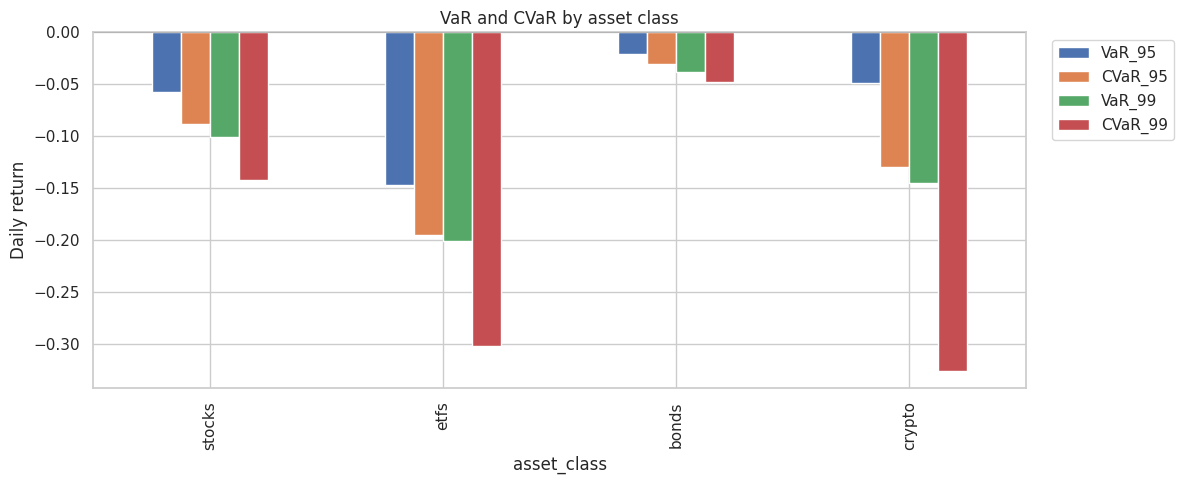

In [7]:
fig, ax = plt.subplots()
comparison[["VaR_95", "CVaR_95", "VaR_99", "CVaR_99"]].plot.bar(ax=ax)
ax.set_ylabel("Daily return")
ax.set_title("VaR and CVaR by asset class")
ax.axhline(0, color="black", linewidth=0.6)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 5. Sensitivity to the confidence level

Sweeping `confidence` from 0.90 to 0.999 shows how quickly the tail estimate becomes noisier as we push deeper into the distribution. The two curves diverge at higher confidence levels — CVaR's tail mean is far more sensitive to extreme observations than VaR's percentile.

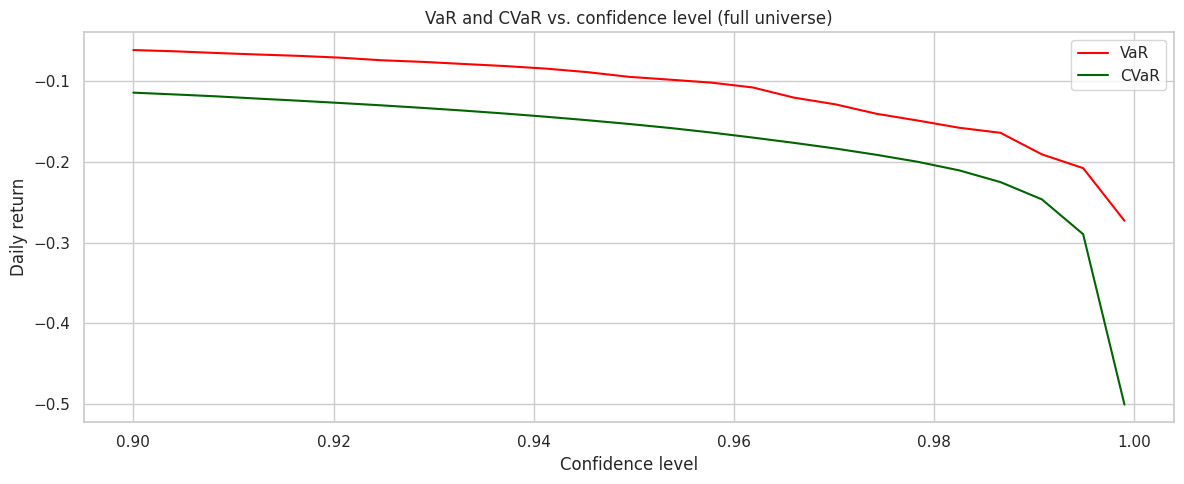

In [8]:
levels = np.linspace(0.90, 0.999, 25)
var_curve = [get_var(all_prices, c) for c in levels]
cvar_curve = [get_cvar(all_prices, c) for c in levels]

fig, ax = plt.subplots()
ax.plot(levels, var_curve, label="VaR", color="red")
ax.plot(levels, cvar_curve, label="CVaR", color="darkgreen")
ax.set_xlabel("Confidence level")
ax.set_ylabel("Daily return")
ax.set_title("VaR and CVaR vs. confidence level (full universe)")
ax.legend()
fig.tight_layout()
plt.show()